# Keypoint Annotation Audit

Audit the completeness of the three falx keypoints stored in annotation JSON files.

Each slice is classified as:

- **Complete** — all three keypoints are present
- **Absent** — none are present
- **Partial** — only one or two are present

The majority comparison is based on **Complete** versus **Absent** slices.


## 1. Setup

In [1]:
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.data.annotations.models import load_annotation

METADATA_PATH = Path("../data/train/annotated.csv")
ANNOTATIONS_DIR = Path("../data/train/annotations")

RELATIVE_PATH_COLUMN = "relative_path"

KEYPOINT_NAMES = (
    "AnteriorFalxAttachment",
    "PosteriorFalxAttachment",
    "OutermostPointOfTheFalx",
)

## 2. Load Metadata

In [2]:
metadata = pd.read_csv(METADATA_PATH)

if RELATIVE_PATH_COLUMN not in metadata.columns:
    raise ValueError(f"Metadata must contain {RELATIVE_PATH_COLUMN!r}.")

relative_paths = metadata[RELATIVE_PATH_COLUMN].dropna().astype(str).tolist()

print(f"Slices to audit: {len(relative_paths):,}")

Slices to audit: 4,959


## 3. Audit Annotations

In [3]:
def keypoint_state(relative_path: str) -> str:
    """Classify the keypoint annotation for one slice."""
    path = ANNOTATIONS_DIR / f"{relative_path}.json"
    annotation = load_annotation(path)
    keypoints = annotation.keypoints

    if not keypoints:
        return "Absent"

    present = sum(keypoints.get(name) is not None for name in KEYPOINT_NAMES)

    if present == len(KEYPOINT_NAMES):
        return "Complete"
    if present == 0:
        return "Absent"

    return "Partial"


with ThreadPoolExecutor() as executor:
    states = list(executor.map(keypoint_state, relative_paths))

print(f"Audited {len(states):,} slices")

Audited 4,959 slices


## 4. Summary

In [4]:
STATE_ORDER = ["Complete", "Absent", "Partial"]

counts = (
    pd.Series(states, name="state")
    .value_counts()
    .reindex(STATE_ORDER, fill_value=0)
    .astype(int)
)

summary = pd.DataFrame(
    {
        "count": counts,
        "percentage": counts / counts.sum(),
    }
)

display(summary.style.format({"percentage": "{:.2%}"}))

complete = int(counts["Complete"])
absent = int(counts["Absent"])
partial = int(counts["Partial"])

if complete > absent:
    majority = "Complete"
elif absent > complete:
    majority = "Absent"
else:
    majority = "Tie"

print(f"Majority: {majority}")
print(f"Complete: {complete:,}")
print(f"Absent:   {absent:,}")
print(f"Partial:  {partial:,}")

,count,percentage
state,,
Complete,1728,34.85%
Absent,3231,65.15%
Partial,0,0.00%


Majority: Absent
Complete: 1,728
Absent:   3,231
Partial:  0


## 5. Plot

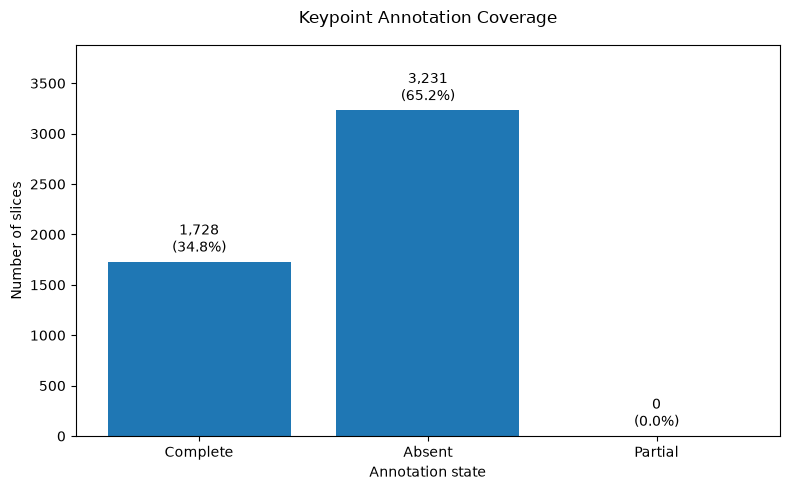

In [5]:
labels = counts.index.astype(str).tolist()
values = counts.to_numpy(dtype=int)
total = int(values.sum())

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(labels, values)

ax.set_title(
    "Keypoint Annotation Coverage",
    pad=16,
)
ax.set_xlabel("Annotation state")
ax.set_ylabel("Number of slices")

ax.set_ylim(0, max(values) * 1.2)

ax.bar_label(
    bars,
    labels=[f"{count:,}\n({count / total:.1%})" for count in values],
    padding=4,
)

fig.tight_layout()
plt.show()